<a href="https://colab.research.google.com/github/KANISHKA-EEE/kanishka-codeboosters-2026/blob/main/Day_4/Day_4_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#install pyspark
!pip install pyspark --quiet
print('PySpark installation completed')

PySpark installation completed


In [2]:
#import pyspark modules and create sparksession
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
#create sparksession
spark=SparkSession.builder \
        .appName('Day4_BigData_Sales') \
        .config('saprk.sql.adaptive.enabled','true') \
        .getOrCreate()
print(f'Spark version : {spark.version}')
print(f'SparkSession : ACTIVE')
print(f'Application :{spark.sparkContext.appName}')

Spark version : 4.0.2
SparkSession : ACTIVE
Application :Day4_BigData_Sales


In [5]:
#bronze
df_bronze=spark.read \
       .option('header','true') \
       .option("inferSchema", "true") \
       .csv('large_sales_data.csv')
print('=== BRONZE LAYER - Raw Data ===')
print(f'Rows :{df_bronze.count()}')
print(f'Columns:{len(df_bronze.columns)}')
print(f'Names :{df_bronze.columns}')
print()
df_bronze.printSchema()

=== BRONZE LAYER - Raw Data ===
Rows :5000
Columns:13
Names :['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [6]:
#first row and summary statistics
print('Frist 5 rows:')
df_bronze.show(5,truncate=False)
print('\nBasic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

Frist 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [7]:
#for last 5
df_bronze.tail(5)

[Row(order_id=5996, customer_name='Ananya Das', product='Mouse', category='Accessories', quantity=13, unit_price=800, revenue=10400, order_date=datetime.date(2023, 11, 18), city='Bangalore', region='South', sales_rep='Meera Patel', payment_method='Net Banking', order_status='Cancelled'),
 Row(order_id=5997, customer_name='Suresh Rao', product='Webcam', category='Accessories', quantity=9, unit_price=2500, revenue=22500, order_date=datetime.date(2023, 6, 7), city='Chennai', region='South', sales_rep='Sunita Rao', payment_method='Credit Card', order_status='Delivered'),
 Row(order_id=5998, customer_name='Arjun Nair', product='Webcam', category='Accessories', quantity=1, unit_price=2500, revenue=2500, order_date=datetime.date(2023, 4, 7), city='Jaipur', region='North', sales_rep='Kavya Reddy', payment_method='Net Banking', order_status='Cancelled'),
 Row(order_id=5999, customer_name='Arjun Nair', product='Laptop', category='Electronics', quantity=14, unit_price=45000, revenue=630000, order

In [10]:
#save bronze layer as Parquet
df_bronze.write \
       .mode('overwrite') \
       .parquet('sales_bronze.parquet')
print('Bronze Parquet saved: sales_bronze.parquet')

Bronze Parquet saved: sales_bronze.parquet


In [11]:
import os

def get_dir_size(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / 1024

    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))

    return total / 1024


csv_size = get_dir_size("large_sales_data.csv")
parquet_size = get_dir_size("sales_bronze.parquet")

reduction = (1 - parquet_size / csv_size) * 100

print(f"\nCSV size : {csv_size:.1f} KB")
print(f"Parquet size : {parquet_size:.1f} KB")
print(f"Reduction : {reduction:.2f}% smaller")
print(f"\nAt 1 TB scale: CSV = 1000 GB -> Parquet = {1000 * (1 - reduction / 100):.0f} GB")


CSV size : 529.3 KB
Parquet size : 55.1 KB
Reduction : 89.59% smaller

At 1 TB scale: CSV = 1000 GB -> Parquet = 104 GB


In [12]:
print('Frist 5 rows:')
df_bronze.show(5,truncate=False)
print('\nBasic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()


Frist 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [13]:
#add unit_price+revenue
print('Frist 5 rows:')
df_bronze.show(5,truncate=False)
print('\nBasic statistics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue',col('unit_price')+col('revenue')).alias('total').describe().show()

Frist 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [14]:
df_silver=df_bronze \
   .dropDuplicates() \
   .dropna(subset=['order_id','product','revenue'])
df_silver=df_silver.withColumn(
    'order_date',
    to_date(col('order_date'), 'dd-MM-yyyy')
)
df_silver=df_silver \
     .withColumn('order_year',year(col('order_date'))) \
     .withColumn('order_month',month(col('order_date')))
df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue') > 30000, 'High')
     .when(col('revenue') > 10000, 'Medium')
     .otherwise('Low')
)
print(f'Silver layer rows:{df_silver.count()}')
print('New columns added: order_year,order_month,revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(8)

Silver layer rows:5000
New columns added: order_year,order_month,revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|            High|
|    Webcam|  35000|      2023|         11|            High|
|    Laptop| 360000|      2023|          1|            High|
+----------+-------+----------+-----------+----------------+
only showing top 8 rows


In [15]:
#duplicate products removed
df_silver=df_bronze \
   .dropDuplicates() \
   .dropna(subset=['order_id','product','revenue'])
df_silver=df_silver.withColumn(
    'order_date',
    to_date(col('order_date'), 'dd-MM-yyyy')
)
df_silver=df_silver \
     .withColumn('order_year',year(col('order_date'))) \
     .withColumn('order_month',month(col('order_date')))
df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue') > 30000, 'High')
     .when(col('revenue') > 10000, 'Medium')
     .otherwise('Low')
)
print("Duplicate products removed:")

df_bronze.groupBy("product") \
    .count() \
    .filter(col("count") > 1) \
    .show(truncate=False)

print(f'Silver layer rows:{df_silver.count()}')
print('New columns added: order_year,order_month,revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(8)

Duplicate products removed:
+----------+-----+
|product   |count|
+----------+-----+
|Speaker   |470  |
|Webcam    |532  |
|USB Hub   |527  |
|Laptop    |502  |
|Mouse     |492  |
|Tablet    |532  |
|Printer   |488  |
|Keyboard  |495  |
|Monitor   |481  |
|Headphones|481  |
+----------+-----+

Silver layer rows:5000
New columns added: order_year,order_month,revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|            High|
|    Webcam|  35000|      2023|         11|            High|
|    Laptop| 

In [16]:
#silver
df_silver.write \
     .mode('overwrite') \
     .parquet('sales_silver.parquet')
print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size: {get_dir_size("sales_silver.parquet"):.1f}KB')
df_verify=spark.read.parquet('sales_silver.parquet')
print(f'Read-back rows: {df_verify.count()} (should match Silver count )')
df_verify.printSchema()

Silver Parquet saved: sales_silver.parquet
Silver size: 59.8KB
Read-back rows: 5000 (should match Silver count )
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [17]:
#bronze
df_silver.write \
     .mode('overwrite') \
     .parquet('sales_silver.parquet')
print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size: {get_dir_size("sales_silver.parquet"):.1f}KB')
print(f'Bronze size:{get_dir_size("sales_bronze.parquet"):.1f}KB')
df_verify=spark.read.parquet('sales_silver.parquet')
print(f'Read-back rows: {df_verify.count()} (should match Silver count )')
df_verify.printSchema()

Silver Parquet saved: sales_silver.parquet
Silver size: 59.8KB
Bronze size:55.1KB
Read-back rows: 5000 (should match Silver count )
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [18]:
top_products=df_silver \
    .groupBy('product') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.avg('revenue').alias('avg_order_revenue')
    )\
    .orderBy('total_revenue',ascending=False)\
    .limit(5)
print('=== Top 5 Products by Revenue ===')
top_products.show(truncate=False)

=== Top 5 Products by Revenue ===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |182700000    |502       |363944.22310756973|
|Tablet |135104000    |532       |253954.8872180451 |
|Monitor|82126000     |481       |170740.12474012474|
|Printer|44544000     |488       |91278.68852459016 |
|Speaker|16317000     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [19]:

top_products=df_silver \
    .groupBy('product') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.round(F.avg('revenue'), 2).alias('avg_order_revenue')
    )\
    .orderBy('total_revenue',ascending=False)\
    .limit(10)
print('=== Top 5 Products by Revenue ===')
top_products.show(truncate=False)

=== Top 5 Products by Revenue ===
+----------+-------------+----------+-----------------+
|product   |total_revenue|num_orders|avg_order_revenue|
+----------+-------------+----------+-----------------+
|Laptop    |182700000    |502       |363944.22        |
|Tablet    |135104000    |532       |253954.89        |
|Monitor   |82126000     |481       |170740.12        |
|Printer   |44544000     |488       |91278.69         |
|Speaker   |16317000     |470       |34717.02         |
|Headphones|13541500     |481       |28152.81         |
|Webcam    |10982500     |532       |20643.8          |
|Keyboard  |4878000      |495       |9854.55          |
|Mouse     |3207200      |492       |6518.7           |
|USB Hub   |2447400      |527       |4644.02          |
+----------+-------------+----------+-----------------+



In [20]:

top_products=df_silver \
    .groupBy('region') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders'),
        F.round(F.avg('revenue'), 2).alias('avg_order_revenue'),
        F.countDistinct('customer_name').alias('unique_customers'),
    )\
    .orderBy('total_revenue',ascending=False)\
    .limit(10)
print('Top 5 Products by Revenue')
top_products.show(truncate=False)

Top 5 Products by Revenue
+------+-------------+----------+-----------------+----------------+
|region|total_revenue|num_orders|avg_order_revenue|unique_customers|
+------+-------------+----------+-----------------+----------------+
|West  |198275600    |2021      |98107.67         |15              |
|South |147145900    |1483      |99221.78         |15              |
|North |99878400     |995       |100380.3         |15              |
|East  |50547700     |501       |100893.61        |15              |
+------+-------------+----------+-----------------+----------------+



In [21]:
monthly_trend = df_silver \
    .groupBy('order_month') \
    .agg(
        F.sum('revenue').alias('monthly_revenue'),
        F.count('order_id').alias('monthly_orders')
    ) \
    .orderBy('order_month')

print("Monthly Revenue and Orders Trend")

monthly_trend.show()


Monthly Revenue and Orders Trend
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|       41068200|           423|
|          2|       34485400|           375|
|          3|       40031200|           451|
|          4|       38857100|           390|
|          5|       39984500|           423|
|          6|       40707400|           390|
|          7|       42640700|           405|
|          8|       43718500|           418|
|          9|       37640200|           398|
|         10|       47839000|           479|
|         11|       44577100|           419|
|         12|       44298300|           429|
+-----------+---------------+--------------+



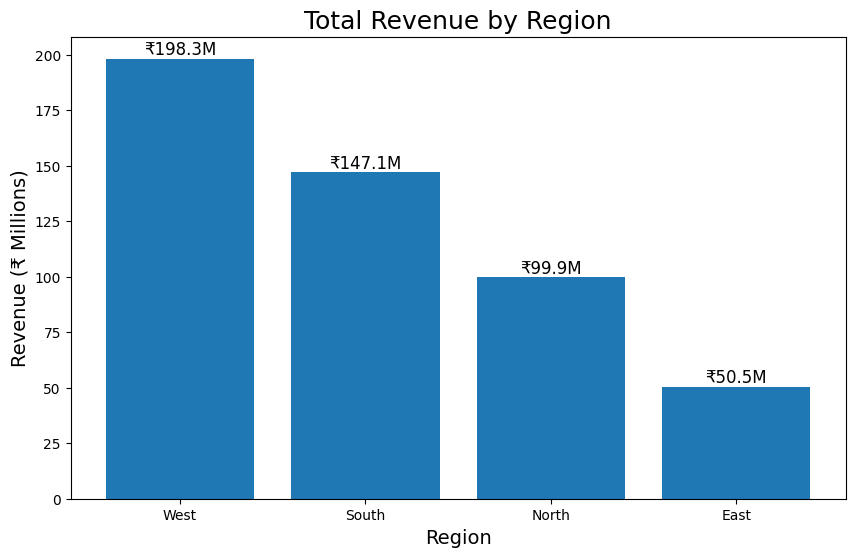

In [22]:
# Region wise total revenue
region_revenue = df_silver \
.groupBy('region') \
.agg(
    F.sum('revenue').alias('total_revenue')
) \
.orderBy(F.col('total_revenue').desc())

# Convert PySpark DataFrame to Pandas
region_pd = region_revenue.toPandas()

# Convert revenue into Millions
region_pd['revenue_million'] = region_pd['total_revenue'] / 1000000

# Plot Bar Chart
plt.figure(figsize=(10,6))

bars = plt.bar(
    region_pd['region'],
    region_pd['revenue_million']
)

# Title and Labels
plt.title('Total Revenue by Region', fontsize=18)

plt.xlabel('Region', fontsize=14)

plt.ylabel('Revenue (₹ Millions)', fontsize=14)

# Value labels on bars
for i in range(len(region_pd)):

    plt.text(
        bars[i].get_x() + bars[i].get_width()/2,
        bars[i].get_height(),
        f"₹{region_pd['revenue_million'][i]:.1f}M",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.show()